In [14]:
import tensorflow as tf
from tensorflow import keras
from keras.utils import image_dataset_from_directory

In [24]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
files.upload() #upload zip file here

In [11]:
!unzip "archive (1).zip"


Archive:  archive (1).zip
  inflating: PlantVillage/Potato___Early_blight/001187a0-57ab-4329-baff-e7246a9edeb0___RS_Early.B 8178.JPG  
  inflating: PlantVillage/Potato___Early_blight/002a55fb-7a3d-4a3a-aca8-ce2d5ebc6925___RS_Early.B 8170.JPG  
  inflating: PlantVillage/Potato___Early_blight/009c8c31-f22d-4ffd-8f16-189c6f06c577___RS_Early.B 7885.JPG  
  inflating: PlantVillage/Potato___Early_blight/00d8f10f-5038-4e0f-bb58-0b885ddc0cc5___RS_Early.B 8722.JPG  
  inflating: PlantVillage/Potato___Early_blight/0182e991-97f0-4805-a1f7-6e1b4306d518___RS_Early.B 7015.JPG  
  inflating: PlantVillage/Potato___Early_blight/02578b86-b234-4ac0-9bc3-691b5610e2bf___RS_Early.B 7562.JPG  
  inflating: PlantVillage/Potato___Early_blight/0267d4ca-522e-4ca0-b1a2-ce925e5b54a2___RS_Early.B 7020.JPG  
  inflating: PlantVillage/Potato___Early_blight/028f9b73-142f-499a-9c7b-d7c1ed5e5506___RS_Early.B 8546.JPG  
  inflating: PlantVillage/Potato___Early_blight/034959c1-f1e8-4a79-a6d5-3c1d14efa2f3___RS_Early.B 7136

In [18]:
from keras.utils import image_dataset_from_directory

In [54]:
dataset = image_dataset_from_directory(
    directory = 'PlantVillage',
    image_size = (255,255),
    shuffle = True,
    batch_size = 32,
    seed = 123   # controls randomness
)

Found 2152 files belonging to 3 classes.


In [28]:
class_names = dataset.class_names

In [29]:
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [30]:
for image_batch,label_batch in dataset.take(1):
  print('Image Batch Shape',image_batch.shape)
  print('Single Image ',image_batch[0])
  print('Label Image Batch',label_batch.numpy)

Image Batch Shape (1, 255, 255, 3)
Single Image  tf.Tensor(
[[[158.00587  150.00587  161.00587 ]
  [160.00392  152.00392  163.00392 ]
  [161.00587  153.00587  164.00587 ]
  ...
  [109.00004   97.00004  107.00004 ]
  [109.01376   97.01376  107.01376 ]
  [123.97269  111.97269  121.97269 ]]

 [[158.98824  150.98824  161.98824 ]
  [158.9882   150.9882   161.9882  ]
  [158.9823   150.9823   161.9823  ]
  ...
  [119.007965 107.007965 117.007965]
  [116.01773  104.01773  114.01773 ]
  [124.9472   112.9472   122.9472  ]]

 [[156.96077  148.96077  159.96077 ]
  [156.94508  148.94508  159.94508 ]
  [155.94116  147.94116  158.94116 ]
  ...
  [122.0196   110.0196   120.0196  ]
  [116.064545 104.064545 114.064545]
  [118.974625 106.974625 116.974625]]

 ...

 [[164.0333   155.0333   160.0333  ]
  [166.02548  157.02548  162.02548 ]
  [167.0195   158.0195   163.0195  ]
  ...
  [124.8932   111.8932   118.8932  ]
  [117.03686  104.03686  111.03686 ]
  [129.07431  116.07431  123.07431 ]]

 [[166.98436  

In [26]:
len(class_names)

3

In [32]:
import matplotlib.pyplot as plt

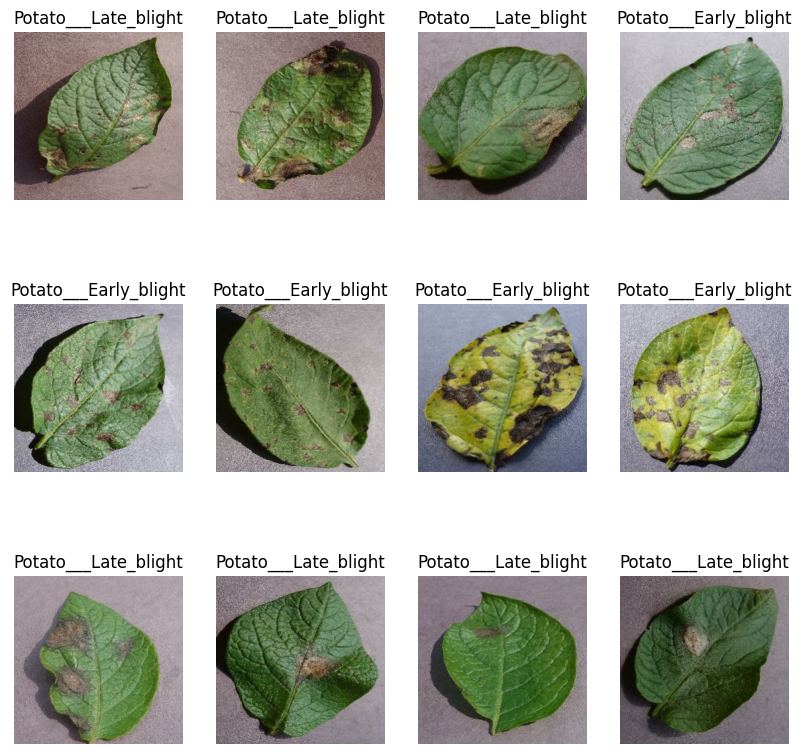

In [33]:
# Create a blank figure (canvas) to display multiple images
plt.figure(figsize=(10, 10))   # width=10 inches, height=10 inches

# Take only ONE batch from the dataset
# dataset.take(1) → gives 1 batch (not 1 image)
for image_batch, labels_batch in dataset.take(1):

    # image_batch → batch of images
    # shape example: (32, 224, 224, 3)
    # 32 images, each 224x224, 3 color channels

    # labels_batch → batch of labels
    # shape example: (32,)
    # 32 labels corresponding to 32 images

    for i in range(12):  # we want to display first 12 images

        # Create a subplot grid:
        # 3 rows, 4 columns, position = i+1
        ax = plt.subplot(3, 4, i + 1)

        # image_batch[i] → selects one image from batch
        # .numpy() → converts TensorFlow tensor → NumPy array
        # .astype("uint8") → converts to image-friendly format (0–255 integers)
        plt.imshow(image_batch[i].numpy().astype("uint8"))

        # labels_batch[i] → numeric label (0 or 1)
        # class_names[...] → converts number → actual class name
        plt.title(class_names[labels_batch[i]])

        # Remove axis numbers (clean display)
        plt.axis("off")

In [39]:
len(dataset)  #means batch-1 ---> 32 images .. it means it has 68 batches

68

In [48]:
train_size = 0.8
len(dataset)*train_size

54.400000000000006

In [49]:
train_ds = dataset.take(54)
len(train_ds)

54

In [50]:
test_ds = dataset.skip(54)
len(test_ds)

14

In [51]:
val_size = 0.1
len(dataset)*val_size

6.800000000000001

In [52]:
val_ds = test_ds.take(6)
len(val_ds)

6

In [53]:
test_ds = test_ds.skip(6)
len(test_ds)

8

In [55]:
# =========================================================
# Optimized Dataset Pipeline (Train + Val + Test)
# =========================================================

import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE   # TensorFlow automatically decides best buffer size


# -------------------------
# TRAIN DATASET
# -------------------------
train_ds = (
    train_ds

    .cache()
    # Stores dataset in memory after first epoch
    # Avoids re-reading images from disk → faster training

    .shuffle(1000)
    # Randomly shuffles training data
    # 1000 = shuffle buffer size
    # Larger buffer → better randomness

    .prefetch(buffer_size=AUTOTUNE)
    # Prepares next batch while GPU trains on current batch
    # Improves hardware utilization
)


# -------------------------
# VALIDATION DATASET
# -------------------------
val_ds = (
    val_ds

    .cache()
    # Cache validation data for faster evaluation

    .prefetch(buffer_size=AUTOTUNE)
    # Prefetch improves validation speed
    # No shuffle → keeps validation consistent
)


# -------------------------
# TEST DATASET
# -------------------------
test_ds = (
    test_ds

    .cache()
    # Cache test data

    .prefetch(buffer_size=AUTOTUNE)
    # Prefetch speeds up testing
    # No shuffle for test dataset
)


In [60]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Rescaling,
    Resizing,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)


In [66]:
resize_and_rescale = Sequential([
  Resizing(255,255),
  Rescaling(1./255)
])

In [64]:
data_augmentation = tf.keras.Sequential([
  RandomFlip("horizontal_and_vertical"),
  RandomRotation(0.2),
])

In [65]:
#Applying Data Augmentation to Train Dataset
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

In [74]:
model = Sequential()

# Input Layer
model.add(Input(shape=(255, 255, 3)))

# Rescaling Layer
model.add(resize_and_rescale)

# Conv Block 1
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Conv Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Conv Block 3
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Conv Block 4
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Conv Block 5
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Conv Block 6
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Classifier
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))


In [72]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 255, 255, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 253, 253, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 124, 124, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [78]:
history = model.fit(train_ds,batch_size=32,epochs=20,validation_data=val_ds,verbose=1)

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 27s 482ms/step - accuracy: 0.9624 - loss: 0.1019 - val_accuracy: 0.9844 - val_loss: 0.0456
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 362ms/step - accuracy: 0.9632 - loss: 0.0994 - val_accuracy: 0.9531 - val_loss: 0.0937
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 341ms/step - accuracy: 0.9594 - loss: 0.0992 - val_accuracy: 0.9792 - val_loss: 0.0538
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 364ms/step - accuracy: 0.9642 - loss: 0.0990 - val_accuracy: 0.9740 - val_loss: 0.0687
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 366ms/step - accuracy: 0.9696 - loss: 0.0960 - val_accuracy: 0.9844 - val_loss: 0.0454
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 30s 555ms/step - accuracy: 0.9728 - loss: 0.0745 - val_accuracy: 0.9792 - val_loss: 0.0687
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 32s 390ms/step - accuracy: 0.9771 - loss: 0.0556 - val_accuracy: 0.9844 - val_loss: 0.0482
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 28s 521ms/step - accuracy: 0.9722 - loss: 0.0608 - val_accu

In [79]:
loss,acc = model.evaluate(test_ds)
print('Test Acc',acc)
loss,acc = model.evaluate(train_ds)
print('Train Acc',acc)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9737 - loss: 0.0667
Test Acc 0.9784482717514038
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 340ms/step - accuracy: 0.9938 - loss: 0.0211
Train Acc 0.9942129850387573


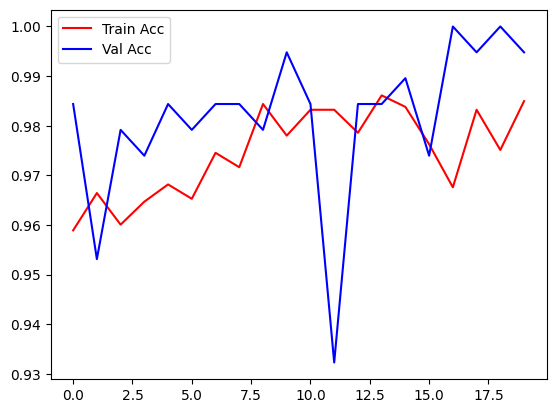

In [82]:
plt.plot(history.history['accuracy'],color='red',label='Train Acc')
plt.plot(history.history['val_accuracy'],color='blue',label='Val Acc')
plt.legend()
plt.show()

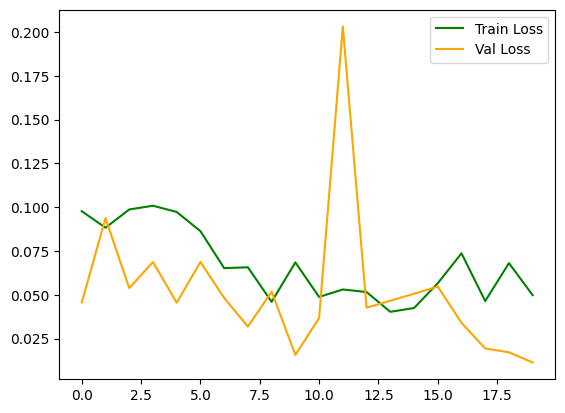

In [83]:
plt.plot(history.history['loss'],color='green',label='Train Loss')
plt.plot(history.history['val_loss'],color='orange',label='Val Loss')
plt.legend()
plt.show()

In [84]:
model.save("crop_model.h5")

#Prediction

In [85]:
model = tf.keras.models.load_model('crop_model.h5')

first image to predict
actual label: Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 893ms/step
predicted label: Potato___Late_blight


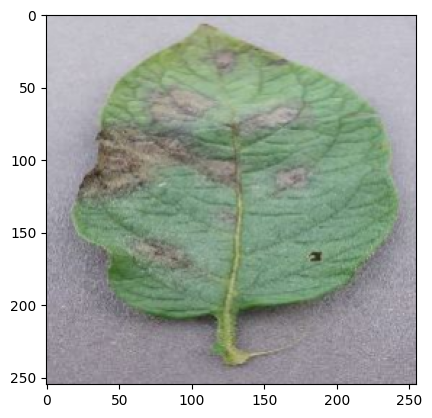

In [86]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):

    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()

    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])

    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


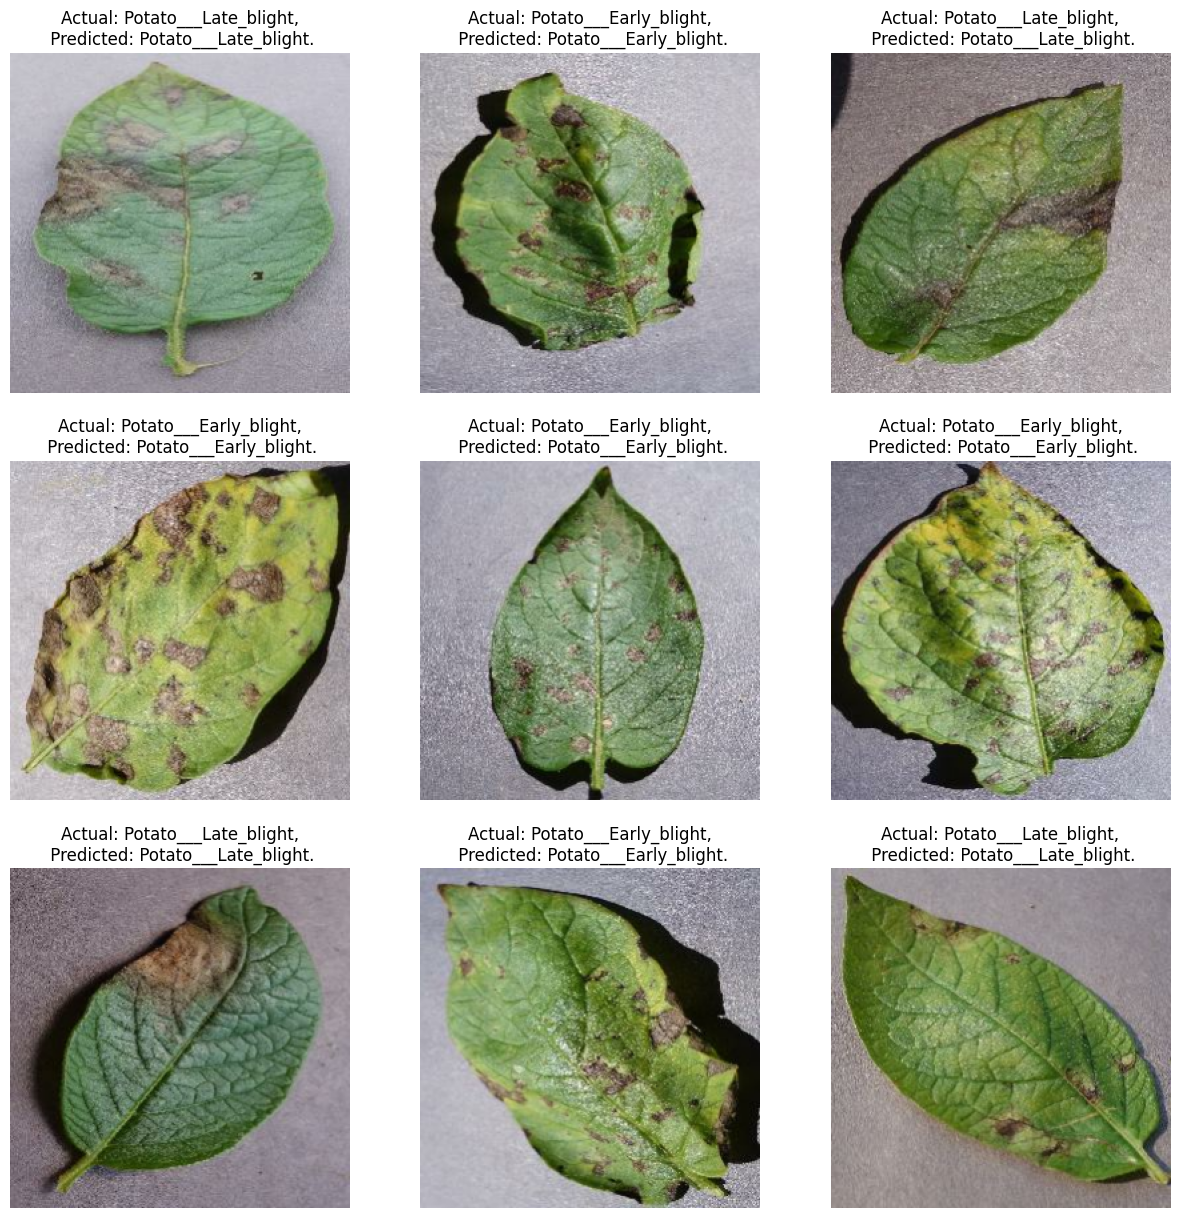

In [90]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        actual_class = class_names[labels[i]]
        prediction = model.predict(images)
        predicted_class = class_names[np.argmax(prediction[i])]


        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.")

        plt.axis("off")